# Green Line Gate Expansion Analysis

**Extension of enforcement allocation model to non-gated Green Line surface stops.**

Estimates whether the MBTA should install fare gates at Green Line surface stations using a cost-benefit framework. Station-level boardings pulled from MBTA Fall 2024 ridership data.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns

# --- Data source ---
RIDERSHIP_FP = "data/input_data/Fall_2024_MBTA_Rail_Ridership_by_SDP_Time_Period,_Route_Line,_and_Stop.csv"  # MBTA Open Data Portal.

# --- Fare and evasion parameters ---
FARE = 2.40                          # Standard MBTA subway/bus fare.
EVASION_GATED = 0.01                 # ~1% evasion on gated subway. (FMCB 2019 board presentation)
EVASION_SURFACE = 0.10               # ~10% evasion on Green Line surface/honor system. (FMCB 2019)
EVASION_DELTA = EVASION_SURFACE - EVASION_GATED  # 9pp recoverable.

# --- Annualization multipliers ---
# Convert avg daily boardings to annual by day type.
ANNUAL_WEEKDAYS = 260                # ~52 weeks x 5 days.
ANNUAL_SATURDAYS = 52
ANNUAL_SUNDAYS = 53

# --- Gate cost parameters ---
GATE_COST_BASE = 75_000              # Per-unit gate hardware + installation, mid estimate. (AFC 2.0 audit)
ANNUAL_MAINTENANCE_RATE = 0.05       # 5% of capital per year for maintenance. (Industry rule of thumb)

# --- Behavioral parameters ---
SHORT_HAUL_EXPOSURE_BASE = 0.75      # Base proportion of surface trips < 900 sec. (Barabino et al. 2015)

# --- MBTA line colors ---
BRANCH_COLORS = {"B": "#00843D", "C": "#64A70B", "D": "#00834d", "E": "#008150"}

## Section 1 — Green Line Surface Station Data

Loads Fall 2024 MBTA ridership data (weekday + weekend) and filters to non-gated Green Line surface stops. Branch assignments are based on MBTA system geography.

In [47]:
STOP_TO_BRANCH = {
    # B Branch (Kenmore -> Boston College).
    "Blandford Street": "B", "Boston University East": "B",
    "Boston University Central": "B", "Amory Street": "B",
    "Babcock Street": "B", "Packard's Corner": "B",
    "Harvard Avenue": "B", "Griggs Street": "B",
    "Allston Street": "B", "Warren Street": "B",
    "Washington Street": "B", "Sutherland Road": "B",
    "Chiswick Road": "B", "Chestnut Hill Avenue": "B",
    "South Street": "B", "Boston College": "B",
    # C Branch (Kenmore -> Cleveland Circle).
    "Saint Mary's Street": "C", "Hawes Street": "C",
    "Kent Street": "C", "Coolidge Corner": "C",
    "Summit Avenue": "C", "Brandon Hall": "C",
    "Dean Road": "C", "Englewood Avenue": "C",
    "Cleveland Circle": "C", "Tappan Street": "C",
    "Washington Square": "C",
    # D Branch (Kenmore -> Riverside).
    "Brookline Village": "D", "Brookline Hills": "D",
    "Beaconsfield": "D", "Reservoir": "D",
    "Chestnut Hill": "D", "Newton Centre": "D",
    "Newton Highlands": "D", "Eliot": "D",
    "Waban": "D", "Woodland": "D", "Riverside": "D",
    # E Branch (Copley -> Heath Street).
    "Northeastern University": "E", "Fenway": "E",
    "Longwood Medical Area": "E", "Longwood": "E",
    "Museum of Fine Arts": "E", "Brigham Circle": "E",
    "Fenwood Road": "E", "Mission Park": "E",
    "Riverway": "E", "Back of the Hill": "E",
    "Heath Street": "E", "Fairbanks Street": "E",
    "Saint Paul Street": "E",
}

BRANCH_ORDER = {
    "B": ["Blandford Street", "Boston University East", "Boston University Central",
          "Amory Street", "Babcock Street", "Packard's Corner", "Harvard Avenue",
          "Griggs Street", "Allston Street", "Warren Street", "Washington Street",
          "Sutherland Road", "Chiswick Road", "Chestnut Hill Avenue", "South Street",
          "Boston College"],
    "C": ["Saint Mary's Street", "Hawes Street", "Kent Street", "Coolidge Corner",
          "Summit Avenue", "Tappan Street", "Dean Road", "Englewood Avenue",
          "Brandon Hall", "Washington Square", "Cleveland Circle"],
    "D": ["Brookline Village", "Brookline Hills", "Beaconsfield", "Reservoir",
          "Chestnut Hill", "Newton Centre", "Newton Highlands", "Eliot",
          "Waban", "Woodland", "Riverside"],
    "E": ["Northeastern University", "Fenway", "Longwood Medical Area", "Longwood",
          "Museum of Fine Arts", "Brigham Circle", "Fenwood Road", "Mission Park",
          "Riverway", "Fairbanks Street", "Saint Paul Street",
          "Back of the Hill", "Heath Street"],
}

In [48]:
raw = pd.read_csv(RIDERSHIP_FP, encoding="utf-8-sig")
gl = raw[raw["route_id"] == "Green"].copy()

# Aggregate total boardings per stop and day type.
by_day = gl.groupby(["stop_name", "day_type_name"]).agg(
    total_ons=("total_ons", "sum"),
    service_days=("number_service_days", "first"),
).reset_index()
by_day["avg_daily"] = by_day["total_ons"] / by_day["service_days"]

# Pivot to get weekday/saturday/sunday columns per stop.
pivot = by_day.pivot_table(index="stop_name", columns="day_type_name", values="avg_daily", fill_value=0)

# Annualize: weekday_avg * 260 + saturday_avg * 52 + sunday_avg * 53.
pivot["estimated_annual_boardings"] = (
    pivot.get("Weekday", 0) * ANNUAL_WEEKDAYS +
    pivot.get("Saturday", 0) * ANNUAL_SATURDAYS +
    pivot.get("Sunday", 0) * ANNUAL_SUNDAYS
).astype(int)

pivot["avg_daily_boardings"] = pivot["estimated_annual_boardings"] / 365
stop_totals = pivot[["estimated_annual_boardings", "avg_daily_boardings"]].reset_index()

# Filter to surface stops only.
surface = stop_totals[stop_totals["stop_name"].isin(STOP_TO_BRANCH)].copy()
surface["branch"] = surface["stop_name"].map(STOP_TO_BRANCH)

# Assign gates_needed based on daily boardings.
surface["gates_needed"] = np.where(
    surface["avg_daily_boardings"] >= 800, 4,
    np.where(surface["avg_daily_boardings"] >= 400, 3, 2)
)

def assign_short_haul(row):
    """Interpolate short_haul_exposure by stop position within branch (inner=0.90, outer=0.60)."""
    order = BRANCH_ORDER.get(row["branch"], [])
    if row["stop_name"] in order:
        idx = order.index(row["stop_name"])
        frac = idx / max(len(order) - 1, 1)
        return round(0.90 - frac * 0.30, 2)  # 0.90 at inner -> 0.60 at outer.
    return SHORT_HAUL_EXPOSURE_BASE

surface["short_haul_exposure"] = surface.apply(assign_short_haul, axis=1)

# --- Derived columns ---
surface["enforcement_score"] = surface["estimated_annual_boardings"] * (1 + surface["short_haul_exposure"])  # Barabino et al. 2015.
surface["annual_revenue_recovered"] = EVASION_DELTA * surface["estimated_annual_boardings"] * FARE  # FMCB 2019.
surface["gate_capital"] = surface["gates_needed"] * GATE_COST_BASE
surface["annual_maintenance"] = surface["gate_capital"] * ANNUAL_MAINTENANCE_RATE
surface["net_annual_revenue"] = surface["annual_revenue_recovered"] - surface["annual_maintenance"]
surface["break_even_years"] = surface["gate_capital"] / surface["net_annual_revenue"]

stations = surface.rename(columns={"stop_name": "station_name"}).reset_index(drop=True)

print(f"Surface stations: {len(stations)}")
print(f"Total gates needed: {stations['gates_needed'].sum()}")
print(f"Total annual boardings (weekday+weekend): {stations['estimated_annual_boardings'].sum():,}")
print(f"Total annual revenue recovered: ${stations['annual_revenue_recovered'].sum():,.0f}")
print(f"Total capital: ${stations['gate_capital'].sum():,.0f}")
stations[["branch", "station_name", "avg_daily_boardings", "estimated_annual_boardings",
          "gates_needed", "short_haul_exposure"]].sort_values("estimated_annual_boardings", ascending=False).head(15)

Surface stations: 51
Total gates needed: 125
Total annual boardings (weekday+weekend): 7,984,761
Total annual revenue recovered: $1,724,708
Total capital: $9,375,000


day_type_name,branch,station_name,avg_daily_boardings,estimated_annual_boardings,gates_needed,short_haul_exposure
17,C,Coolidge Corner,1277.452055,466270,4,0.81
38,D,Riverside,1190.561644,434555,4,0.60
25,B,Harvard Avenue,1186.202740,432964,4,0.78
35,E,Northeastern University,615.367123,224609,3,0.90
49,B,Washington Street,610.838356,222956,3,0.70
36,B,Packard's Corner,604.010959,220464,3,0.80
10,E,Brigham Circle,603.449315,220259,3,0.78
12,D,Brookline Village,581.556164,212268,3,0.90
0,B,Allston Street,580.660274,211941,3,0.74
47,B,Warren Street,550.668493,200994,3,0.72


## Section 2 — Enforcement Score & Priority Ranking

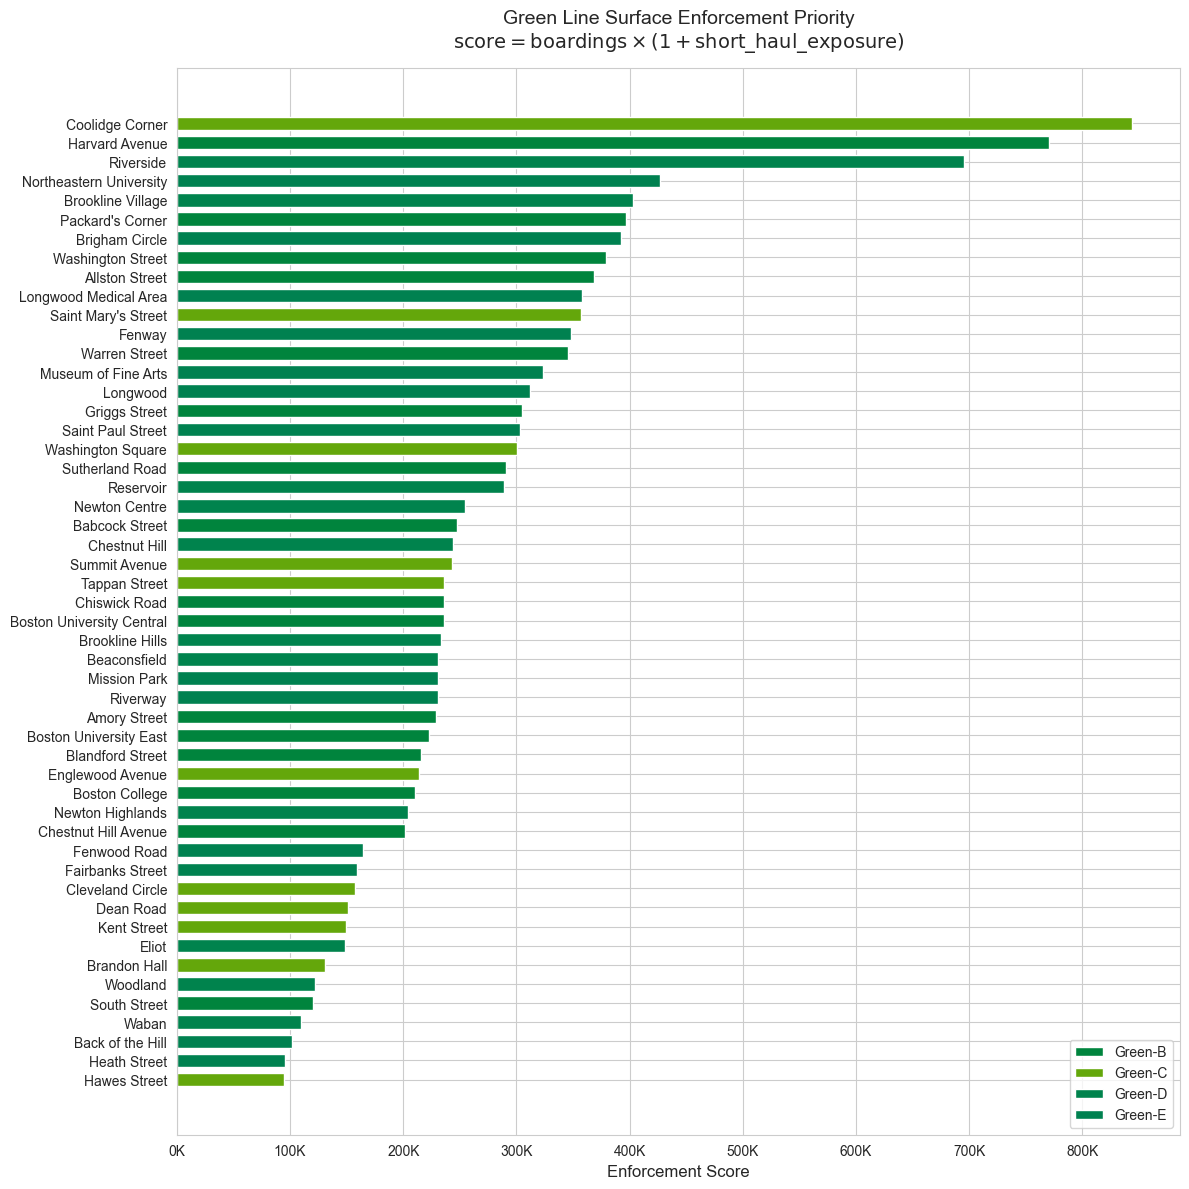

In [49]:
# Chart 2a: Green Line Surface Enforcement Priority.
sorted_stations = stations.sort_values("enforcement_score", ascending=True)

fig, ax = plt.subplots(figsize=(12, 12))
colors = [BRANCH_COLORS[b] for b in sorted_stations["branch"]]
ax.barh(sorted_stations["station_name"], sorted_stations["enforcement_score"], color=colors, height=0.7)

ax.set_xlabel("Enforcement Score", fontsize=12)
ax.set_title("Green Line Surface Enforcement Priority\n"
             r"$\mathrm{score = boardings \times (1 + short\_haul\_exposure)}$",
             fontsize=14, pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

legend_handles = [Patch(facecolor=BRANCH_COLORS[b], label=f"Green-{b}") for b in ["B", "C", "D", "E"]]
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("assets/gl_enforcement_priority.png", dpi=300, bbox_inches="tight")
plt.show()

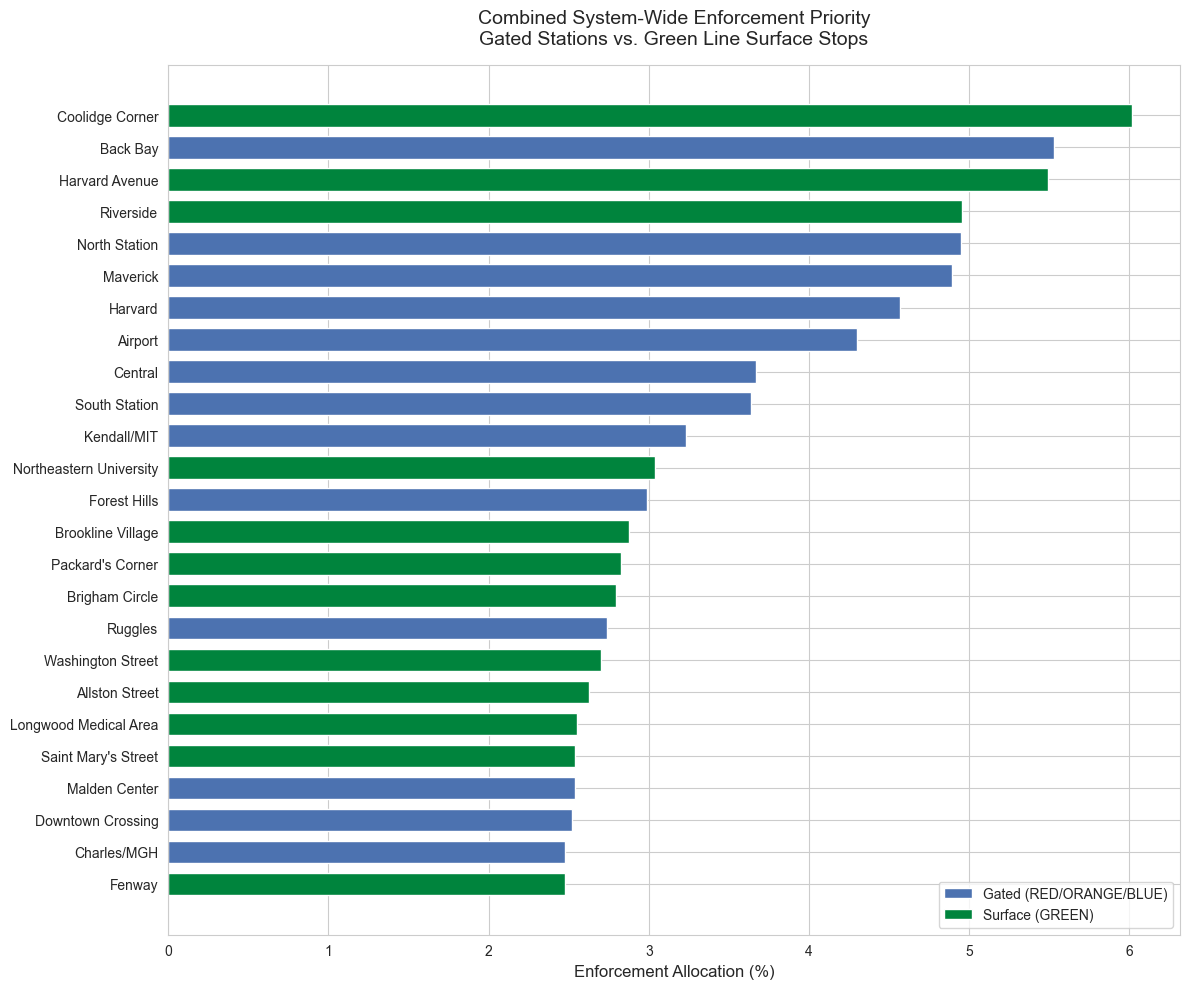

In [50]:
# Chart 2b: Combined System-Wide Enforcement Priority.
informed = pd.read_csv("data/output_data/informed_allocation.csv")

gated_scores = informed[["source_station", "daily_avg"]].copy()
gated_scores.columns = ["station_name", "pct_allocation"]
gated_scores["system"] = "Gated (RED/ORANGE/BLUE)"

# Normalize surface scores to the same % scale.
surface_scores = stations[["station_name", "enforcement_score"]].copy()
total_enforcement = surface_scores["enforcement_score"].sum()
surface_scores["pct_allocation"] = (
    surface_scores["enforcement_score"] / total_enforcement
) * gated_scores["pct_allocation"].sum()
surface_scores["system"] = "Surface (GREEN)"
surface_scores = surface_scores[["station_name", "pct_allocation", "system"]]

combined = pd.concat([gated_scores, surface_scores], ignore_index=True)
combined = combined.sort_values("pct_allocation", ascending=True).tail(25)

fig, ax = plt.subplots(figsize=(12, 10))
colors = ["#00843D" if s == "Surface (GREEN)" else "#4C72B0" for s in combined["system"]]
ax.barh(combined["station_name"], combined["pct_allocation"], color=colors, height=0.7)

ax.set_xlabel("Enforcement Allocation (%)", fontsize=12)
ax.set_title("Combined System-Wide Enforcement Priority\nGated Stations vs. Green Line Surface Stops",
             fontsize=14, pad=15)
ax.legend(handles=[
    Patch(facecolor="#4C72B0", label="Gated (RED/ORANGE/BLUE)"),
    Patch(facecolor="#00843D", label="Surface (GREEN)"),
], loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("assets/gl_combined_enforcement.png", dpi=300, bbox_inches="tight")
plt.show()

## Section 3 — Evasion & Revenue Comparison

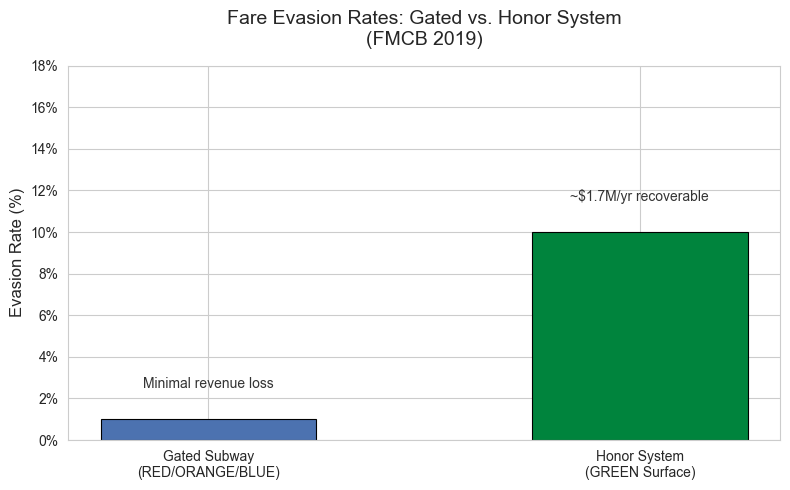

In [51]:
# Chart 3a: Evasion Rate Comparison — Gated vs. Honor System. (FMCB 2019)
fig, ax = plt.subplots(figsize=(8, 5))
categories = ["Gated Subway\n(RED/ORANGE/BLUE)", "Honor System\n(GREEN Surface)"]
rates = [EVASION_GATED * 100, EVASION_SURFACE * 100]

bars = ax.bar(categories, rates, color=["#4C72B0", "#00843D"], width=0.5, edgecolor="black", linewidth=0.8)

ax.annotate("Minimal revenue loss", xy=(0, rates[0]), xytext=(0, rates[0] + 1.5),
            ha="center", fontsize=10, color="#333")
total_surface_rev = stations["annual_revenue_recovered"].sum()
ax.annotate(f"~${total_surface_rev/1e6:.1f}M/yr recoverable",
            xy=(1, rates[1]), xytext=(1, rates[1] + 1.5),
            ha="center", fontsize=10, color="#333")

ax.set_ylabel("Evasion Rate (%)", fontsize=12)
ax.set_title("Fare Evasion Rates: Gated vs. Honor System\n(FMCB 2019)", fontsize=14, pad=15)
ax.set_ylim(0, 18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
plt.savefig("assets/gl_evasion_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

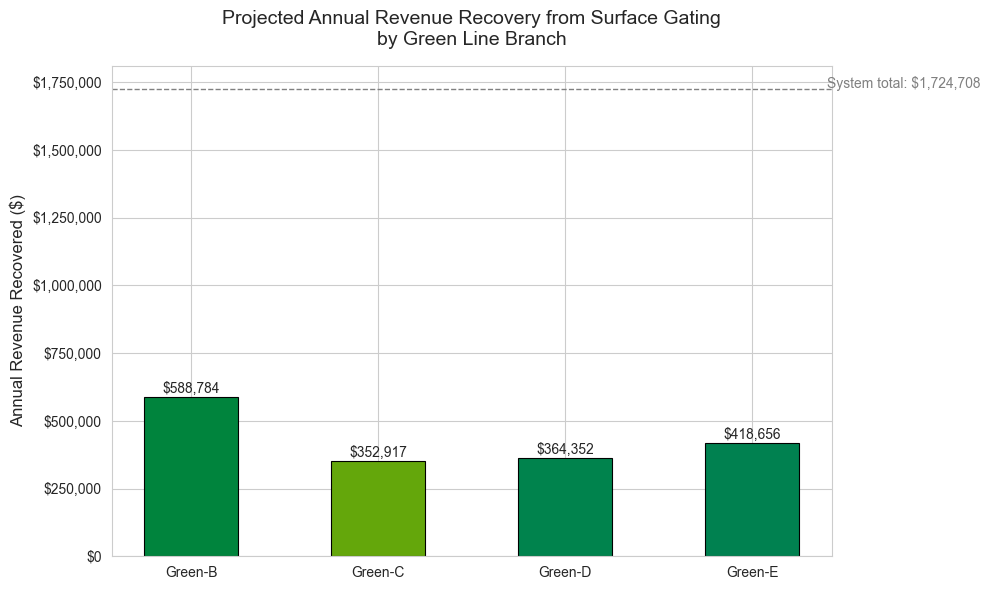

In [52]:
# Chart 3b: Annual Revenue Recovery by Green Line Branch.
branch_summary = stations.groupby("branch").agg(
    total_boardings=("estimated_annual_boardings", "sum"),
    total_revenue_recovered=("annual_revenue_recovered", "sum"),
    total_gates=("gates_needed", "sum"),
    total_capital=("gate_capital", "sum"),
    station_count=("station_name", "count"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [BRANCH_COLORS[b] for b in branch_summary["branch"]]
bars = ax.bar(branch_summary["branch"].apply(lambda b: f"Green-{b}"),
              branch_summary["total_revenue_recovered"],
              color=bar_colors, width=0.5, edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, branch_summary["total_revenue_recovered"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2_000,
            f"${val:,.0f}", ha="center", va="bottom", fontsize=10)

total_rev = branch_summary["total_revenue_recovered"].sum()
ax.axhline(y=total_rev, color="gray", linestyle="--", linewidth=1)
ax.text(3.4, total_rev + 2_000, f"System total: ${total_rev:,.0f}", fontsize=10, color="gray")

ax.set_ylabel("Annual Revenue Recovered ($)", fontsize=12)
ax.set_title("Projected Annual Revenue Recovery from Surface Gating\nby Green Line Branch",
             fontsize=14, pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("assets/gl_revenue_by_branch.png", dpi=300, bbox_inches="tight")
plt.show()

## Section 4 — Cost Model & Break-Even Analysis

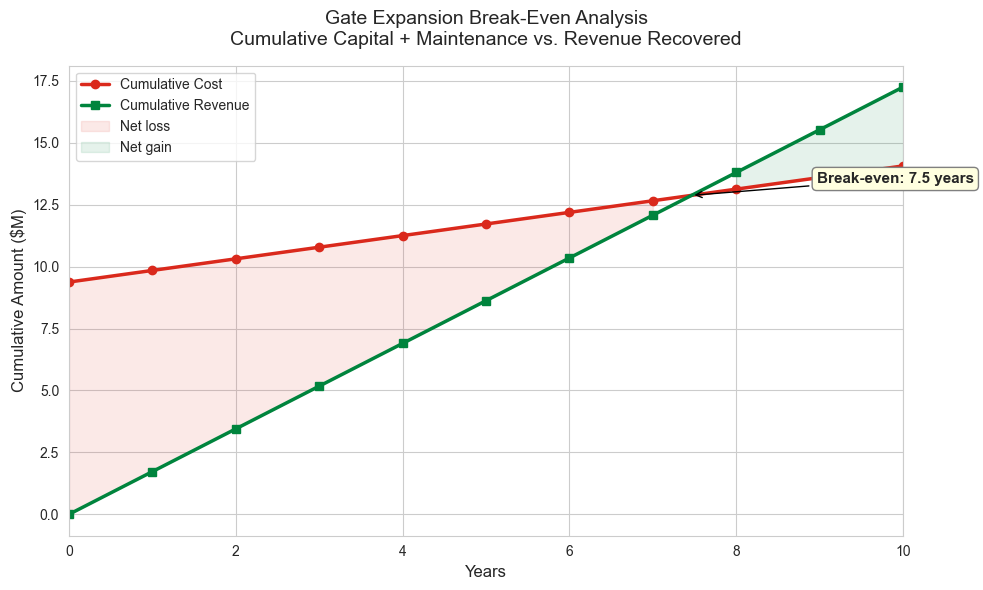

Total capital: $9,375,000
Annual maintenance: $468,750
Annual revenue recovered: $1,724,708
Break-even: 7.5 years


In [53]:
# Chart 4a: Break-Even Waterfall — Cumulative Cost vs. Revenue over 10 years.
total_capital = stations["gate_capital"].sum()
total_annual_maintenance = stations["annual_maintenance"].sum()
total_annual_revenue = stations["annual_revenue_recovered"].sum()

years = np.arange(0, 11)
cumulative_cost = total_capital + total_annual_maintenance * years
cumulative_revenue = total_annual_revenue * years

# Linear interpolation for break-even.
net = cumulative_revenue - cumulative_cost
be_year = np.nan
for i in range(len(net) - 1):
    if net[i] < 0 and net[i + 1] >= 0:
        be_year = i + (-net[i]) / (net[i + 1] - net[i])
        break

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(years, cumulative_cost / 1e6, color="#DA291C", linewidth=2.5, marker="o", label="Cumulative Cost")
ax.plot(years, cumulative_revenue / 1e6, color="#00843D", linewidth=2.5, marker="s", label="Cumulative Revenue")

ax.fill_between(years, cumulative_cost / 1e6, cumulative_revenue / 1e6,
                where=(cumulative_revenue < cumulative_cost),
                color="#DA291C", alpha=0.1, label="Net loss")
ax.fill_between(years, cumulative_cost / 1e6, cumulative_revenue / 1e6,
                where=(cumulative_revenue >= cumulative_cost),
                color="#00843D", alpha=0.1, label="Net gain")

if not np.isnan(be_year):
    be_value = total_annual_revenue * be_year / 1e6
    ax.annotate(f"Break-even: {be_year:.1f} years",
                xy=(be_year, be_value), xytext=(be_year + 1.5, be_value + 0.5),
                fontsize=11, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="black"),
                bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))

ax.set_xlabel("Years", fontsize=12)
ax.set_ylabel("Cumulative Amount ($M)", fontsize=12)
ax.set_title("Gate Expansion Break-Even Analysis\nCumulative Capital + Maintenance vs. Revenue Recovered",
             fontsize=14, pad=15)
ax.legend(fontsize=10)
ax.set_xlim(0, 10)

plt.tight_layout()
plt.savefig("assets/gl_breakeven_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Total capital: ${total_capital:,.0f}")
print(f"Annual maintenance: ${total_annual_maintenance:,.0f}")
print(f"Annual revenue recovered: ${total_annual_revenue:,.0f}")
if not np.isnan(be_year):
    print(f"Break-even: {be_year:.1f} years")
else:
    print("Break-even: >10 years")

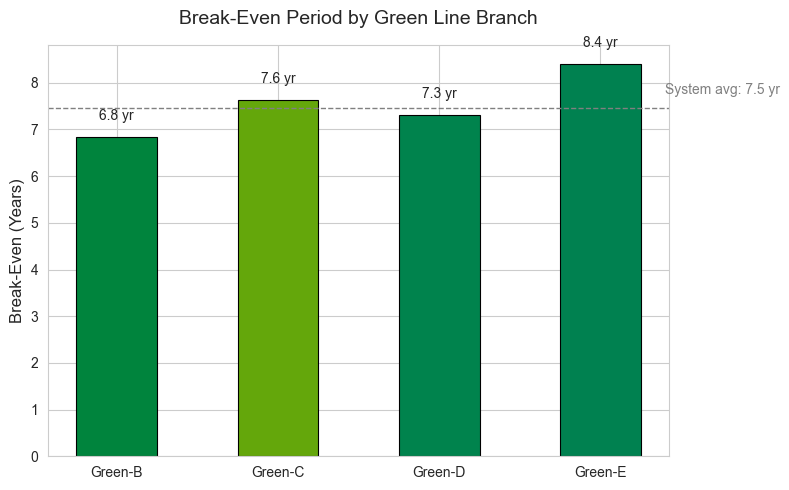

In [54]:
# Chart 4b: Break-Even by Branch.
branch_be = stations.groupby("branch").agg(
    total_capital=("gate_capital", "sum"),
    total_maintenance=("annual_maintenance", "sum"),
    total_revenue=("annual_revenue_recovered", "sum"),
).reset_index()
branch_be["break_even_years"] = branch_be["total_capital"] / (
    branch_be["total_revenue"] - branch_be["total_maintenance"]
)

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = [BRANCH_COLORS[b] for b in branch_be["branch"]]
bars = ax.bar(branch_be["branch"].apply(lambda b: f"Green-{b}"),
              branch_be["break_even_years"],
              color=bar_colors, width=0.5, edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, branch_be["break_even_years"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f} yr", ha="center", va="bottom", fontsize=10)

system_be = total_capital / (total_annual_revenue - total_annual_maintenance)
ax.axhline(y=system_be, color="gray", linestyle="--", linewidth=1)
ax.text(3.4, system_be + 0.3, f"System avg: {system_be:.1f} yr", fontsize=10, color="gray")

ax.set_ylabel("Break-Even (Years)", fontsize=12)
ax.set_title("Break-Even Period by Green Line Branch", fontsize=14, pad=15)

plt.tight_layout()
plt.savefig("assets/gl_breakeven_by_branch.png", dpi=300, bbox_inches="tight")
plt.show()

## Section 5 — Monte Carlo Simulation

In [55]:
N = 10_000
rng = np.random.default_rng(42)

total_gates = stations["gates_needed"].sum()
total_surface_boardings = stations["estimated_annual_boardings"].sum()

# Triangular distributions: (min, mode, max). (Ranges from gate-expansion.md)
evasion_samples = rng.triangular(0.07, 0.10, 0.18, N)
cost_samples = rng.triangular(45_000, 75_000, 110_000, N)

# Vectorized break-even using data-derived boardings.
delta_e_mc = evasion_samples - EVASION_GATED
revenue_mc = delta_e_mc * total_surface_boardings * FARE
capital_mc = cost_samples * total_gates
maintenance_mc = capital_mc * ANNUAL_MAINTENANCE_RATE
net_annual_mc = revenue_mc - maintenance_mc

break_even_mc = np.where(net_annual_mc > 0, capital_mc / net_annual_mc, np.nan)

p5, p50, p95 = np.nanpercentile(break_even_mc, [5, 50, 95])
print(f"Monte Carlo Break-Even (N={N:,}):")
print(f"  5th percentile:  {p5:.1f} years")
print(f"  Median:          {p50:.1f} years")
print(f"  95th percentile: {p95:.1f} years")
print(f"  90% CI: [{p5:.1f}, {p95:.1f}]")

Monte Carlo Break-Even (N=10,000):
  5th percentile:  3.5 years
  Median:          6.3 years
  95th percentile: 12.1 years
  90% CI: [3.5, 12.1]


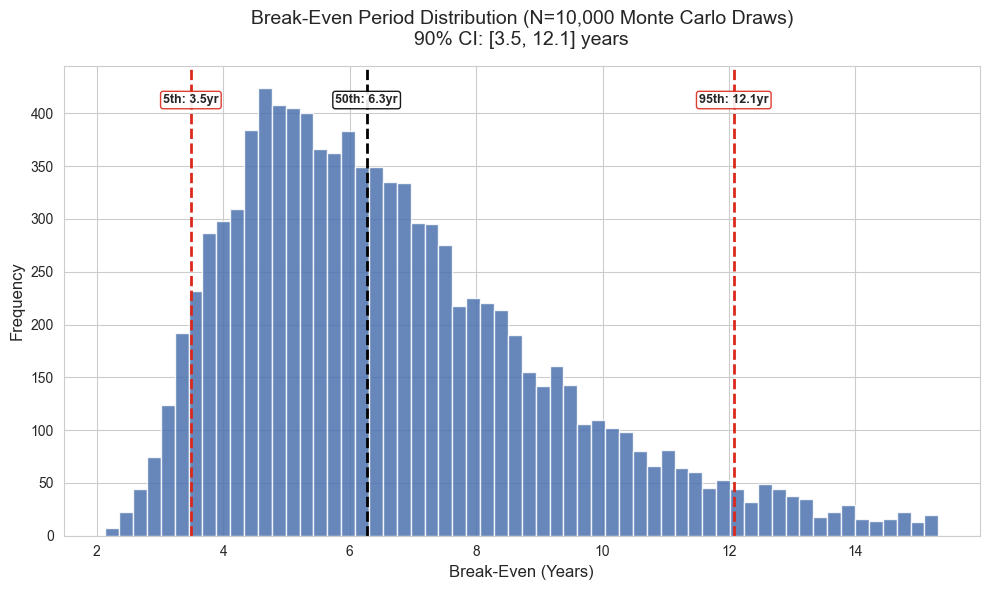

In [56]:
# Chart 5a: Break-Even Distribution (Monte Carlo).
plot_data = break_even_mc[~np.isnan(break_even_mc)]
plot_data = plot_data[plot_data < np.percentile(plot_data, 99)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(plot_data, bins=60, color="#4C72B0", edgecolor="white", alpha=0.85)

for pct, val, color in [("5th", p5, "#DA291C"), ("50th", p50, "black"), ("95th", p95, "#DA291C")]:
    ax.axvline(val, color=color, linewidth=2, linestyle="--")
    ax.text(val, ax.get_ylim()[1] * 0.92, f"{pct}: {val:.1f}yr",
            ha="center", fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.9))

ax.set_xlabel("Break-Even (Years)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title(f"Break-Even Period Distribution (N={N:,} Monte Carlo Draws)\n"
             f"90% CI: [{p5:.1f}, {p95:.1f}] years",
             fontsize=14, pad=15)

plt.tight_layout()
plt.savefig("assets/gl_mc_breakeven_dist.png", dpi=300, bbox_inches="tight")
plt.show()

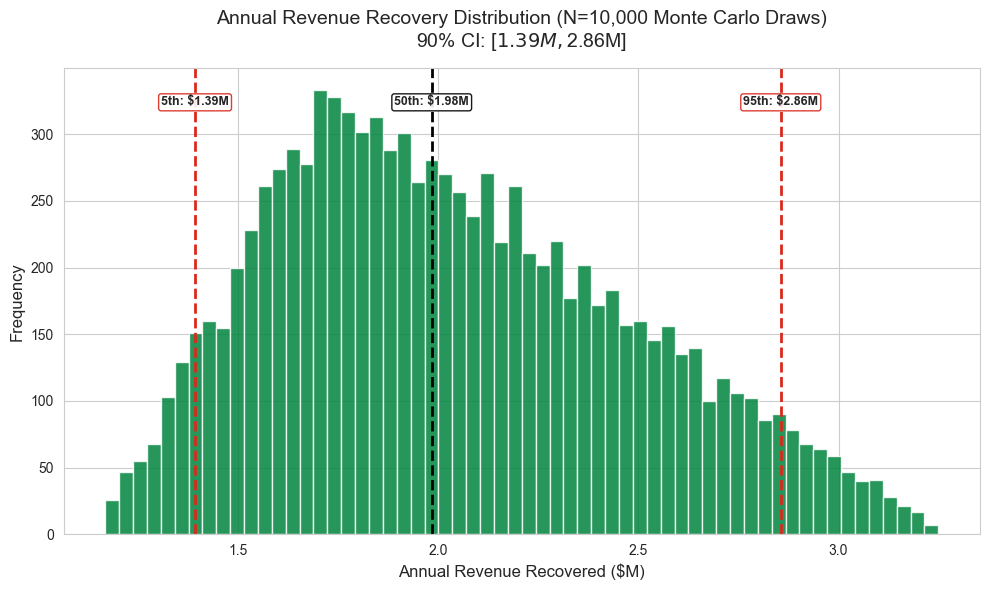

In [57]:
# Chart 5b: Revenue Recovery Distribution (Monte Carlo).
rev_p5, rev_p50, rev_p95 = np.nanpercentile(revenue_mc, [5, 50, 95])

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(revenue_mc / 1e6, bins=60, color="#00843D", edgecolor="white", alpha=0.85)

for pct, val, color in [("5th", rev_p5, "#DA291C"), ("50th", rev_p50, "black"), ("95th", rev_p95, "#DA291C")]:
    ax.axvline(val / 1e6, color=color, linewidth=2, linestyle="--")
    ax.text(val / 1e6, ax.get_ylim()[1] * 0.92, f"{pct}: ${val/1e6:.2f}M",
            ha="center", fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.9))

ax.set_xlabel("Annual Revenue Recovered ($M)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title(f"Annual Revenue Recovery Distribution (N={N:,} Monte Carlo Draws)\n"
             f"90% CI: [${rev_p5/1e6:.2f}M, ${rev_p95/1e6:.2f}M]",
             fontsize=14, pad=15)

plt.tight_layout()
plt.savefig("assets/gl_mc_revenue_dist.png", dpi=300, bbox_inches="tight")
plt.show()

## Section 6 — Summary & Export

In [58]:
# Summary table by branch.
summary = stations.groupby("branch").agg(
    stations_count=("station_name", "count"),
    total_boardings=("estimated_annual_boardings", "sum"),
    total_gates=("gates_needed", "sum"),
    total_capital=("gate_capital", "sum"),
    total_annual_revenue=("annual_revenue_recovered", "sum"),
    total_annual_maintenance=("annual_maintenance", "sum"),
).reset_index()
summary["net_annual_revenue"] = summary["total_annual_revenue"] - summary["total_annual_maintenance"]
summary["break_even_years"] = summary["total_capital"] / summary["net_annual_revenue"]

print("=" * 80)
print("GREEN LINE GATE EXPANSION — SUMMARY BY BRANCH")
print("=" * 80)
for _, row in summary.iterrows():
    print(f"\nBranch {row['branch']}:")
    print(f"  Stations: {row['stations_count']}  |  Gates: {row['total_gates']}")
    print(f"  Annual boardings: {row['total_boardings']:,}")
    print(f"  Capital: ${row['total_capital']:,.0f}  |  Revenue: ${row['total_annual_revenue']:,.0f}/yr")
    print(f"  Break-even: {row['break_even_years']:.1f} years")

print(f"\n{'=' * 80}")
print(f"SYSTEM TOTAL: {len(stations)} stations, {stations['gates_needed'].sum()} gates")
print(f"  Boardings: {stations['estimated_annual_boardings'].sum():,}/yr")
print(f"  Capital: ${total_capital:,.0f}  |  Revenue: ${total_annual_revenue:,.0f}/yr")
print(f"  Break-even: {system_be:.1f} years  |  MC 90% CI: [{p5:.1f}, {p95:.1f}] years")
print(f"{'=' * 80}")

GREEN LINE GATE EXPANSION — SUMMARY BY BRANCH

Branch B:
  Stations: 16  |  Gates: 40
  Annual boardings: 2,725,851
  Capital: $3,000,000  |  Revenue: $588,784/yr
  Break-even: 6.8 years

Branch C:
  Stations: 11  |  Gates: 26
  Annual boardings: 1,633,874
  Capital: $1,950,000  |  Revenue: $352,917/yr
  Break-even: 7.6 years

Branch D:
  Stations: 11  |  Gates: 26
  Annual boardings: 1,686,816
  Capital: $1,950,000  |  Revenue: $364,352/yr
  Break-even: 7.3 years

Branch E:
  Stations: 13  |  Gates: 33
  Annual boardings: 1,938,220
  Capital: $2,475,000  |  Revenue: $418,656/yr
  Break-even: 8.4 years

SYSTEM TOTAL: 51 stations, 125 gates
  Boardings: 7,984,761/yr
  Capital: $9,375,000  |  Revenue: $1,724,708/yr
  Break-even: 7.5 years  |  MC 90% CI: [3.5, 12.1] years


In [59]:
# Export station-level data.
export_cols = [
    "branch", "station_name", "estimated_annual_boardings", "gates_needed",
    "short_haul_exposure", "enforcement_score", "annual_revenue_recovered",
    "gate_capital", "annual_maintenance", "net_annual_revenue", "break_even_years",
]
stations[export_cols].to_csv("data/output_data/green_line_surface_estimates.csv", index=False)
print("Exported to data/output_data/green_line_surface_estimates.csv")

Exported to data/output_data/green_line_surface_estimates.csv
